# S11-26 — Feature Importance Monitoring — Scénario by_equipment

| Champ | Valeur |
|-------|--------|
| **Expériences** | exp_112 (KMeans), exp_113 (Mahalanobis), exp_114 (EWC), exp_115 (HDC) |
| **Scénario** | by_equipment : Pump → Turbine → Compressor |
| **Features** | 4 features : temperature, pressure, vibration, humidity |
| **Sprint** | Sprint 11 — S11-26 |

> **Pré-requis** : lancer S11-24 avant d'exécuter ce notebook :
> ```bash
> python scripts/train_kmeans.py --config configs/ewc_config.yaml  # exp_112
> python scripts/train_mahalanobis.py --config configs/ewc_config.yaml  # exp_113
> python scripts/train_ewc.py --config configs/ewc_config.yaml  # exp_114
> python scripts/train_hdc.py --config configs/hdc_config.yaml  # exp_115
> ```

## Section 1 — Setup, imports et chargement des résultats

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Image

_cwd = Path('.').resolve()
if _cwd.name == 'monitoring_feature_importance':
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == 'cl_eval':
    os.chdir(_cwd.parent.parent)

sys.path.insert(0, str(Path('.').resolve()))

from src.evaluation.feature_importance import (
    FEATURE_NAMES_MONITORING,
    plot_feature_importance,
    plot_feature_importance_comparison,
)

FIGURES_DIR = Path("notebooks/figures/cl_evaluation/monitoring_feature_importance")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPS = {
    "KMeans":      "experiments/exp_112_kmeans_monitoring_by_equipment/results/feature_importance.json",
    "Mahalanobis": "experiments/exp_113_mahalanobis_monitoring_by_equipment/results/feature_importance.json",
    "EWC":         "experiments/exp_114_ewc_monitoring_by_equipment/results/feature_importance.json",
    "HDC":         "experiments/exp_115_hdc_monitoring_by_equipment/results/feature_importance.json",
}

data = {model: json.load(open(path)) for model, path in EXPS.items()}
TASKS = ["Pump", "Turbine", "Compressor"]
print("Chargement OK — modèles :", list(data.keys()))
print("Features :", FEATURE_NAMES_MONITORING)

Chargement OK — modèles : ['KMeans', 'Mahalanobis', 'EWC', 'HDC']
Features : ['temperature', 'pressure', 'vibration', 'humidity']


## Section 2 — Tableau récapitulatif global (ranking par modèle)

In [2]:
rows = {}
for model, d in data.items():
    scores = d["global"]["permutation_importance"]
    rows[model] = {f: scores.get(f, 0.0) for f in FEATURE_NAMES_MONITORING}

df = pd.DataFrame(rows).T  # modèles en lignes, features en colonnes
df_rank = df.rank(axis=1, ascending=False).astype(int)

print("=== Scores d'importance (permutation globale) ===")
display(df.round(4))
print()
print("=== Rang par feature (1 = plus importante) ===")
display(df_rank)

=== Scores d'importance (permutation globale) ===


,temperature,pressure,vibration,humidity
KMeans,0.0347,0.0208,-0.0021,0.0136
Mahalanobis,0.0278,0.0185,0.0241,0.0108
EWC,0.0664,0.0293,0.0397,0.0087
HDC,0.0477,0.0155,0.0297,0.0133



=== Rang par feature (1 = plus importante) ===


,temperature,pressure,vibration,humidity
KMeans,1,2,4,3
Mahalanobis,1,3,2,4
EWC,1,3,2,4
HDC,1,3,2,4


## Section 3 — Barplot groupé global (4 modèles × 4 features)

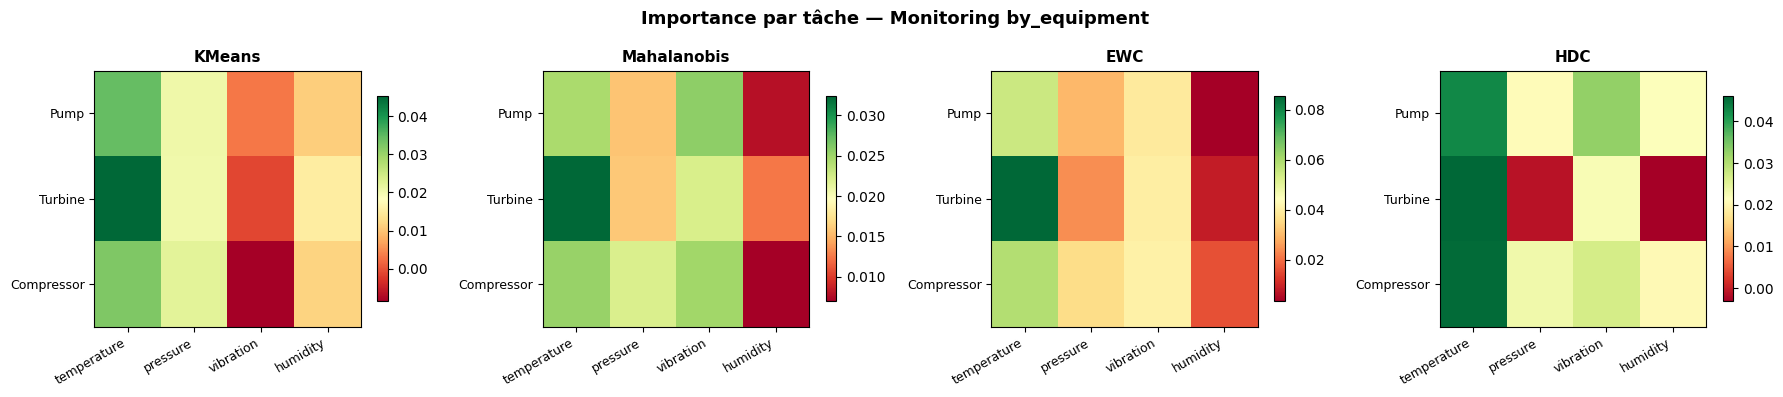

Figure sauvegardée : notebooks/figures/cl_evaluation/monitoring_feature_importance/by_equipment_per_task_heatmap.png


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Importance par tâche — Monitoring by_equipment", fontsize=13, fontweight="bold")

for ax, (model, d) in zip(axes, data.items()):
    mat = np.array([
        [d["per_task"][t]["permutation_importance"].get(f, 0.0) for f in FEATURE_NAMES_MONITORING]
        for t in TASKS
    ])
    im = ax.imshow(mat, aspect="auto", cmap="RdYlGn", vmin=mat.min(), vmax=max(abs(mat).max(), 1e-6))
    ax.set_xticks(range(len(FEATURE_NAMES_MONITORING)))
    ax.set_xticklabels(FEATURE_NAMES_MONITORING, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(TASKS)))
    ax.set_yticklabels(TASKS, fontsize=9)
    ax.set_title(model, fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "by_equipment_per_task_heatmap.png", bbox_inches="tight")
display(Image(str(FIGURES_DIR / "by_equipment_per_task_heatmap.png")))
print(f"Figure sauvegardée : {FIGURES_DIR / 'by_equipment_per_task_heatmap.png'}")

## Section 5 — EWC : permutation vs gradient saliency (normalisés)

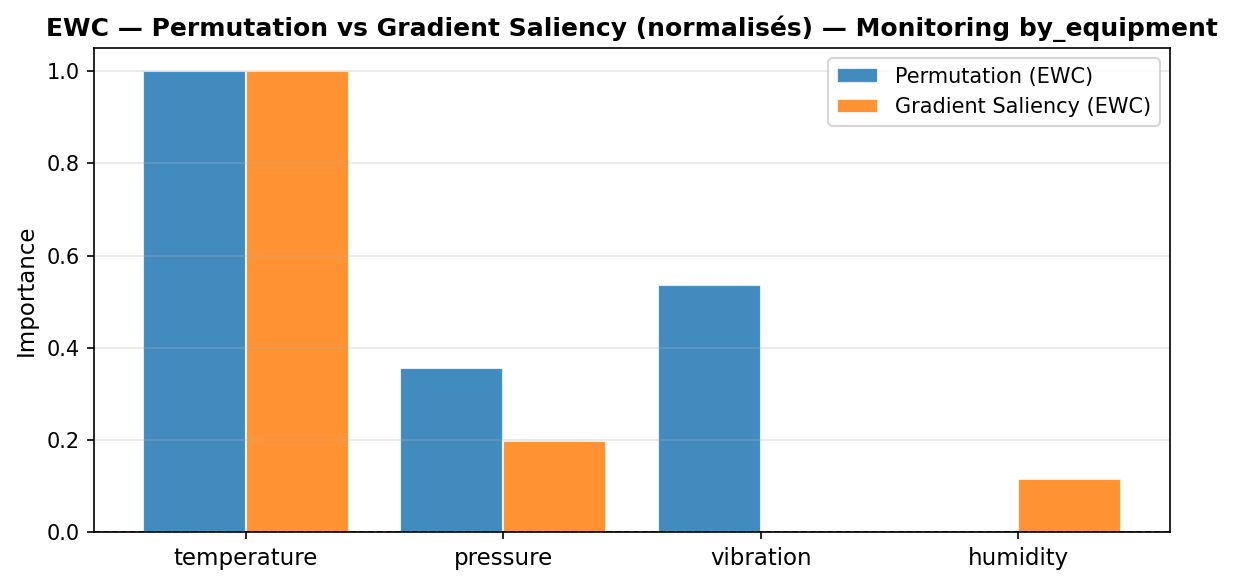

Corrélation de Spearman entre les deux méthodes : ρ = 0.400  (p = 0.600)


In [5]:
from scipy.stats import spearmanr

ewc = data["EWC"]["global"]
perm = ewc["permutation_importance"]
grad = ewc["gradient_saliency"]

def minmax(d):
    vals = np.array(list(d.values()))
    mn, mx = vals.min(), vals.max()
    if mx == mn:
        return {k: 0.0 for k in d}
    return {k: (v - mn) / (mx - mn) for k, v in d.items()}

perm_n = minmax(perm)
grad_n = minmax(grad)

importances_ewc = {"Permutation (EWC)": perm_n, "Gradient Saliency (EWC)": grad_n}
fig = plot_feature_importance_comparison(
    importances_ewc,
    FEATURE_NAMES_MONITORING,
    title="EWC — Permutation vs Gradient Saliency (normalisés) — Monitoring by_equipment",
)
fig.savefig(FIGURES_DIR / "by_equipment_ewc_perm_vs_grad.png", bbox_inches="tight")
display(Image(str(FIGURES_DIR / "by_equipment_ewc_perm_vs_grad.png")))

rho, p = spearmanr(
    [perm_n[f] for f in FEATURE_NAMES_MONITORING],
    [grad_n[f] for f in FEATURE_NAMES_MONITORING],
)
print(f"Corrélation de Spearman entre les deux méthodes : ρ = {rho:.3f}  (p = {p:.3f})")

## Section 6 — HDC : permutation vs feature masking

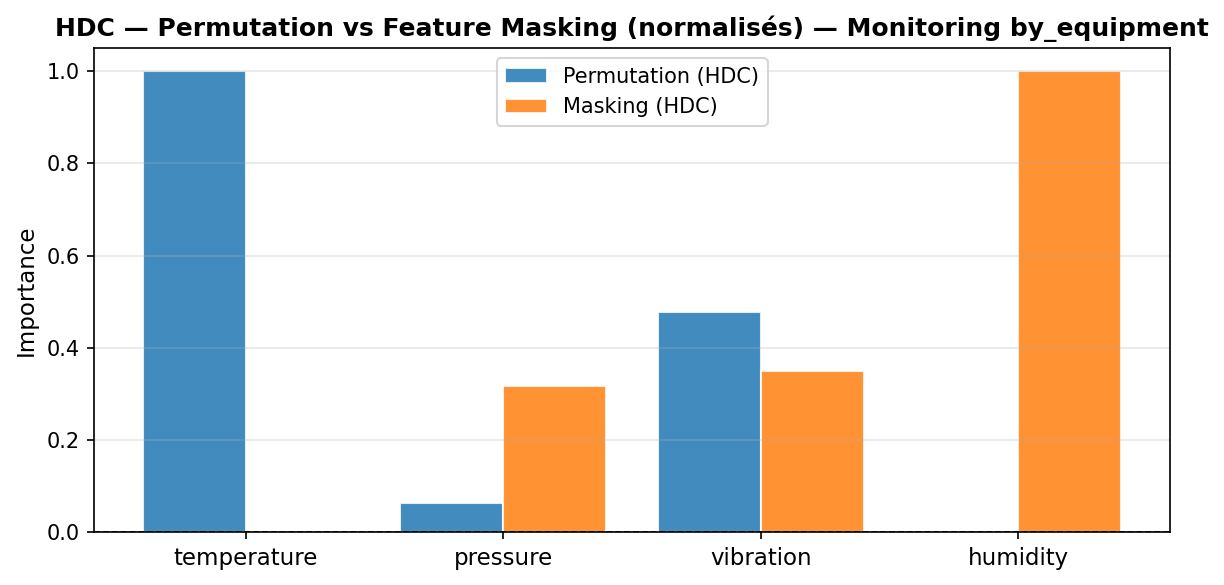

Corrélation Spearman Permutation/Masking (HDC) : ρ = -0.800  (p = 0.200)


In [6]:
hdc = data["HDC"]["global"]
perm_h = hdc["permutation_importance"]
mask_h = hdc["feature_masking_importance"]

perm_h_n = minmax(perm_h)
mask_h_n = minmax(mask_h)

importances_hdc = {"Permutation (HDC)": perm_h_n, "Masking (HDC)": mask_h_n}
fig = plot_feature_importance_comparison(
    importances_hdc,
    FEATURE_NAMES_MONITORING,
    title="HDC — Permutation vs Feature Masking (normalisés) — Monitoring by_equipment",
)
fig.savefig(FIGURES_DIR / "by_equipment_hdc_perm_vs_masking.png", bbox_inches="tight")
display(Image(str(FIGURES_DIR / "by_equipment_hdc_perm_vs_masking.png")))

rho, p = spearmanr(
    [perm_h_n[f] for f in FEATURE_NAMES_MONITORING],
    [mask_h_n[f] for f in FEATURE_NAMES_MONITORING],
)
print(f"Corrélation Spearman Permutation/Masking (HDC) : ρ = {rho:.3f}  (p = {p:.3f})")

## Section 7 — Analyse : Monitoring by_equipment

### Questions clés

**Les 3 types d'équipement ont-ils le même top feature ?**

À compléter après exécution des cellules précédentes. Observer la heatmap (Section 4) :
- Si les couleurs sont homogènes entre Pump/Turbine/Compressor → peu de domain shift sur les features importantes
- Si chaque équipement a un profil distinct → indique que la feature la plus discriminante varie selon l'équipement

**`vibration` est-elle stable ?**

- `vibration` est l'indicateur physique central de la défaillance mécanique
- Sa présence stable dans le top-2 validerait la cohérence physique du modèle
- Un top feature différent entre équipements → opportunité de réduction (feature subset par domaine)

### Notes pour le manuscrit

- Dataset 2 (Monitoring) : seulement 4 features — pas de redondance, chaque feature compte
- Features recommandées pour déploiement MCU : à déterminer d'après heatmap Section 4
- Comparer avec `monitoring_feature_importance/by_location.ipynb` : les features stables entre équipements le sont-elles aussi entre locations ?
- `FIXME(gap2)` : avec 4 features, pas de réduction possible vers < 4 — monitoring est déjà minimal